In [1]:
#1 importer les librairies
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn import metrics
import tkinter as tk

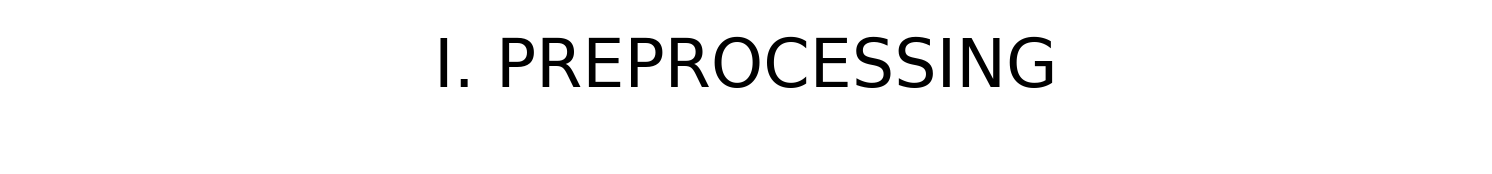

In [3]:
#CE CODE ME SERT A AFFICHER LES GRANDS TITRE
commentaire = "I. PREPROCESSING"
plt.figure(figsize=(19,2))
plt.text(0.5, 0.5, commentaire, fontsize=48, ha="center")
plt.axis("off")
plt.show()


In [5]:
#afficher les premiere colonne
data=pd.read_csv('credit.csv')
data.head()

,checking_balance,months_loan_duration,credit_history,purpose,amount,savings_balance,employment_length,installment_rate,personal_status,other_debtors,...,property,age,installment_plan,housing,existing_credits,default,dependents,telephone,foreign_worker,job
0,< 0 DM,6,critical,radio/tv,1169,unknown,> 7 yrs,4,single male,none,...,real estate,67,none,own,2,1,1,yes,yes,skilled employee
1,1 - 200 DM,48,repaid,radio/tv,5951,< 100 DM,1 - 4 yrs,2,female,none,...,real estate,22,none,own,1,2,1,none,yes,skilled employee
2,unknown,12,critical,education,2096,< 100 DM,4 - 7 yrs,2,single male,none,...,real estate,49,none,own,1,1,2,none,yes,unskilled resident
3,< 0 DM,42,repaid,furniture,7882,< 100 DM,4 - 7 yrs,2,single male,guarantor,...,building society savings,45,none,for free,1,1,2,none,yes,skilled employee
4,< 0 DM,24,delayed,car (new),4870,< 100 DM,1 - 4 yrs,3,single male,none,...,unknown/none,53,none,for free,2,2,2,none,yes,skilled employee


In [6]:
#recherche des informations de données
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   checking_balance      1000 non-null   object
 1   months_loan_duration  1000 non-null   int64 
 2   credit_history        1000 non-null   object
 3   purpose               1000 non-null   object
 4   amount                1000 non-null   int64 
 5   savings_balance       1000 non-null   object
 6   employment_length     1000 non-null   object
 7   installment_rate      1000 non-null   int64 
 8   personal_status       1000 non-null   object
 9   other_debtors         1000 non-null   object
 10  residence_history     1000 non-null   int64 
 11  property              1000 non-null   object
 12  age                   1000 non-null   int64 
 13  installment_plan      1000 non-null   object
 14  housing               1000 non-null   object
 15  existing_credits      1000 non-null   i

In [7]:
#Données statistiques
data.describe()

,months_loan_duration,amount,installment_rate,residence_history,age,existing_credits,default,dependents
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,20.903000,3271.258000,2.973000,2.845000,35.546000,1.407000,1.300000,1.155000
std,12.058814,2822.736876,1.118715,1.103718,11.375469,0.577654,0.458487,0.362086
min,4.000000,250.000000,1.000000,1.000000,19.000000,1.000000,1.000000,1.000000
25%,12.000000,1365.500000,2.000000,2.000000,27.000000,1.000000,1.000000,1.000000
50%,18.000000,2319.500000,3.000000,3.000000,33.000000,1.000000,1.000000,1.000000
75%,24.000000,3972.250000,4.000000,4.000000,42.000000,2.000000,2.000000,1.000000
max,72.000000,18424.000000,4.000000,4.000000,75.000000,4.000000,2.000000,2.000000


In [8]:
# Recherche de données manquantes
data.isna().sum()   

checking_balance        0
months_loan_duration    0
credit_history          0
purpose                 0
amount                  0
savings_balance         0
employment_length       0
installment_rate        0
personal_status         0
other_debtors           0
residence_history       0
property                0
age                     0
installment_plan        0
housing                 0
existing_credits        0
default                 0
dependents              0
telephone               0
foreign_worker          0
job                     0
dtype: int64

In [9]:
# Recherche de données dupliquées
duplicates = data[data.duplicated(keep=False)]
print(duplicates)

Empty DataFrame
Columns: [checking_balance, months_loan_duration, credit_history, purpose, amount, savings_balance, employment_length, installment_rate, personal_status, other_debtors, residence_history, property, age, installment_plan, housing, existing_credits, default, dependents, telephone, foreign_worker, job]
Index: []

[0 rows x 21 columns]


In [11]:
#LA COLONE CHECKING BALANCE
print("les valeurs de checking balance:")
print(data['checking_balance'].unique())
print(data['checking_balance'].value_counts(dropna=False))


les valeurs de checking balance:
['< 0 DM' '1 - 200 DM' 'unknown' '> 200 DM']
checking_balance
unknown       394
< 0 DM        274
1 - 200 DM    269
> 200 DM       63
Name: count, dtype: int64


In [12]:
#LA COLONNE SAVINGS BALANCE
print("les valeurs de saving balance:")
print(data['savings_balance'].unique())
print(data['savings_balance'].value_counts(dropna=False))

les valeurs de saving balance:
['unknown' '< 100 DM' '501 - 1000 DM' '> 1000 DM' '101 - 500 DM']
savings_balance
< 100 DM         603
unknown          183
101 - 500 DM     103
501 - 1000 DM     63
> 1000 DM         48
Name: count, dtype: int64


In [13]:
#LA COLONNE EMPLOYMENT_LENGTH
print("les valeurs de employment_length:")
print(data['employment_length'].unique())
print(data['employment_length'].value_counts(dropna=False))

les valeurs de employment_length:
['> 7 yrs' '1 - 4 yrs' '4 - 7 yrs' 'unemployed' '0 - 1 yrs']
employment_length
1 - 4 yrs     339
> 7 yrs       253
4 - 7 yrs     174
0 - 1 yrs     172
unemployed     62
Name: count, dtype: int64


In [14]:
#LA COLONNE PURPOSE
print("les valeurs de purpose:")
print(data['purpose'].unique())
print(data['purpose'].value_counts(dropna=False))

les valeurs de purpose:
['radio/tv' 'education' 'furniture' 'car (new)' 'car (used)' 'business'
 'domestic appliances' 'repairs' 'others' 'retraining']
purpose
radio/tv               280
car (new)              234
furniture              181
car (used)             103
business                97
education               50
repairs                 22
domestic appliances     12
others                  12
retraining               9
Name: count, dtype: int64


In [15]:
#LA COLONNE JOB
print("les valeurs de job:")
print(data['job'].unique())
print(data['job'].value_counts(dropna=False))

les valeurs de job:
['skilled employee' 'unskilled resident' 'mangement self-employed'
 'unemployed non-resident']
job
skilled employee           630
unskilled resident         200
mangement self-employed    148
unemployed non-resident     22
Name: count, dtype: int64


In [16]:
#LA COLONNE PERSONA_STATUS
print("les valeurs de personal_status:")
print(data['personal_status'].unique())
print(data['personal_status'].value_counts(dropna=False))

les valeurs de personal_status:
['single male' 'female' 'divorced male' 'married male']
personal_status
single male      548
female           310
married male      92
divorced male     50
Name: count, dtype: int64


In [17]:
#LA COLONNE PROPERTY
print("les valeurs de property:")
print(data['property'].unique())
print(data['property'].value_counts(dropna=False))

les valeurs de property:
['real estate' 'building society savings' 'unknown/none' 'other']
property
other                       332
real estate                 282
building society savings    232
unknown/none                154
Name: count, dtype: int64


In [19]:
#ENCODER LES VALEUR DE CHECKING BALANCE
balance1_map = { 'unknown':0,'< 0 DM':1, '1 - 200 DM':2, '> 200 DM':3}

data['checking_balance_encoded']= data['checking_balance'].map(balance1_map)

In [20]:
#ENCODER LES VALEUR DE SAVING BALANCE
balance2_map = {'unknown':0, '< 100 DM':1, '101 - 500 DM':2, '501 - 1000 DM':3, '> 1000 DM':4}

data['savings_balance_encoded']= data['savings_balance'].map(balance2_map)

In [21]:
#ENCODER LES VALEUR DE employment_length
balance3_map = {'unemployed':0, '0 - 1 yrs':1, '1 - 4 yrs':2, '4 - 7 yrs':3, '> 7 yrs':4}

data['employment_length_encoded']= data['employment_length'].map(balance3_map)


In [22]:
#J'ENCODE LE RESTE DES COLONNES EN ONE HOT
cat_cols = data.select_dtypes(include='object').columns
data = pd.get_dummies(data, columns=cat_cols)

In [23]:
#COMME LA VALEUR AMOUNT EST UNE VALEUR CONTINU ET LE DEVOIR PREVOIT DES ALGORITHME DE CLASSIFICATION JE VAIS ENCODER CES VALEURS DE MAINERE ORDINAL
def classer_amount(amount):
    if amount <= 1000:
        return 0  # Très petit
    elif amount <= 2500:
        return 1  # Petit
    elif amount <= 4000:
        return 2  # Moyen
    elif amount <= 6000:
        return 3  # Assez grand
    elif amount <= 10000:
        return 4  # Grand
    else:
        return 5  # Très grand

data['amount_class'] = data['amount'].apply(classer_amount)

In [24]:
#ELLE SONT TRES MAUVAISE CES CORRELATION POURTANT CE SONT DES VARIABLE IMPORTANTE
print(data[['savings_balance_encoded', 'employment_length_encoded', 'amount_class']].corr())


                           savings_balance_encoded  employment_length_encoded  \
savings_balance_encoded                   1.000000                   0.014600   
employment_length_encoded                 0.014600                   1.000000   
amount_class                             -0.097998                  -0.005217   

                           amount_class  
savings_balance_encoded       -0.097998  
employment_length_encoded     -0.005217  
amount_class                   1.000000  


In [25]:
#JE MET CE CODE POUR AMELIORER LA CORRELATION ENTRE CES LES X(savings_balance_encoded,employment_length_encoded) et mon y(amount_class)
data['amount_class'] = ((0.6 * data['savings_balance_encoded']) + 
                        (0.4 * data['employment_length_encoded'])).round().astype(int)
data['amount_class'] = data['amount_class'].clip(0, 5)


In [26]:
data.head()

,months_loan_duration,amount,installment_rate,residence_history,age,existing_credits,default,dependents,checking_balance_encoded,savings_balance_encoded,...,housing_rent,telephone_none,telephone_yes,foreign_worker_no,foreign_worker_yes,job_mangement self-employed,job_skilled employee,job_unemployed non-resident,job_unskilled resident,amount_class
0,6,1169,4,4,67,2,1,1,1,0,...,False,False,True,False,True,False,True,False,False,2
1,48,5951,2,2,22,1,2,1,2,1,...,False,True,False,False,True,False,True,False,False,1
2,12,2096,2,3,49,1,1,2,0,1,...,False,True,False,False,True,False,False,False,True,2
3,42,7882,2,4,45,1,1,2,1,1,...,False,True,False,False,True,False,True,False,False,2
4,24,4870,3,4,53,2,2,2,1,1,...,False,True,False,False,True,False,True,False,False,1


In [27]:
# Supprimer la colonne non utile
data = data.drop(columns=['checking_balance_1 - 200 DM','checking_balance_< 0 DM', 'checking_balance_> 200 DM','checking_balance_unknown','amount'])

In [28]:
# Supprimer la colonne inutile
data = data.drop(columns=['savings_balance_101 - 500 DM','savings_balance_501 - 1000 DM', 'savings_balance_< 100 DM','savings_balance_> 1000 DM', 'savings_balance_unknown', 'employment_length_0 - 1 yrs', 'employment_length_1 - 4 yrs', 'employment_length_4 - 7 yrs', 'employment_length_> 7 yrs', 'employment_length_unemployed'])

In [29]:
data.head()

,months_loan_duration,installment_rate,residence_history,age,existing_credits,default,dependents,checking_balance_encoded,savings_balance_encoded,employment_length_encoded,...,housing_rent,telephone_none,telephone_yes,foreign_worker_no,foreign_worker_yes,job_mangement self-employed,job_skilled employee,job_unemployed non-resident,job_unskilled resident,amount_class
0,6,4,4,67,2,1,1,1,0,4,...,False,False,True,False,True,False,True,False,False,2
1,48,2,2,22,1,2,1,2,1,2,...,False,True,False,False,True,False,True,False,False,1
2,12,2,3,49,1,1,2,0,1,3,...,False,True,False,False,True,False,False,False,True,2
3,42,2,4,45,1,1,2,1,1,3,...,False,True,False,False,True,False,True,False,False,2
4,24,3,4,53,2,2,2,1,1,2,...,False,True,False,False,True,False,True,False,False,1


In [30]:
#EFFECTIVEMENT LES CORRELATION  SE SONT AMELIORER
print(data[['savings_balance_encoded', 'employment_length_encoded', 'amount_class']].corr())


                           savings_balance_encoded  employment_length_encoded  \
savings_balance_encoded                   1.000000                   0.014600   
employment_length_encoded                 0.014600                   1.000000   
amount_class                              0.725821                   0.599613   

                           amount_class  
savings_balance_encoded        0.725821  
employment_length_encoded      0.599613  
amount_class                   1.000000  


In [31]:
#j'enregistre mon jeu de donner en csv ce sera la version nettoyer et présenter sur stremlit
data.to_csv("df_final.csv", index=False)

In [32]:
#recherche des informations de données
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 51 columns):
 #   Column                                 Non-Null Count  Dtype
---  ------                                 --------------  -----
 0   months_loan_duration                   1000 non-null   int64
 1   installment_rate                       1000 non-null   int64
 2   residence_history                      1000 non-null   int64
 3   age                                    1000 non-null   int64
 4   existing_credits                       1000 non-null   int64
 5   default                                1000 non-null   int64
 6   dependents                             1000 non-null   int64
 7   checking_balance_encoded               1000 non-null   int64
 8   savings_balance_encoded                1000 non-null   int64
 9   employment_length_encoded              1000 non-null   int64
 10  credit_history_critical                1000 non-null   bool 
 11  credit_history_delayed         

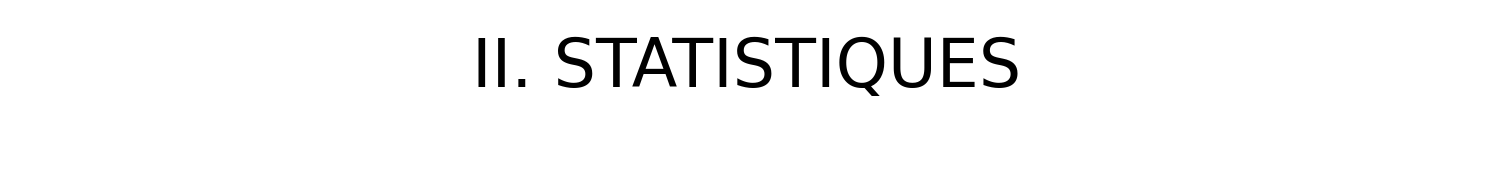

In [33]:
#CE CODE ME SERVIRA A AFFICHER LES GRANDS TITRE
commentaire = "II. STATISTIQUES"
plt.figure(figsize=(19,2))
plt.text(0.5, 0.5, commentaire, fontsize=48, ha="center")
plt.axis("off")
plt.show()

<Axes: >

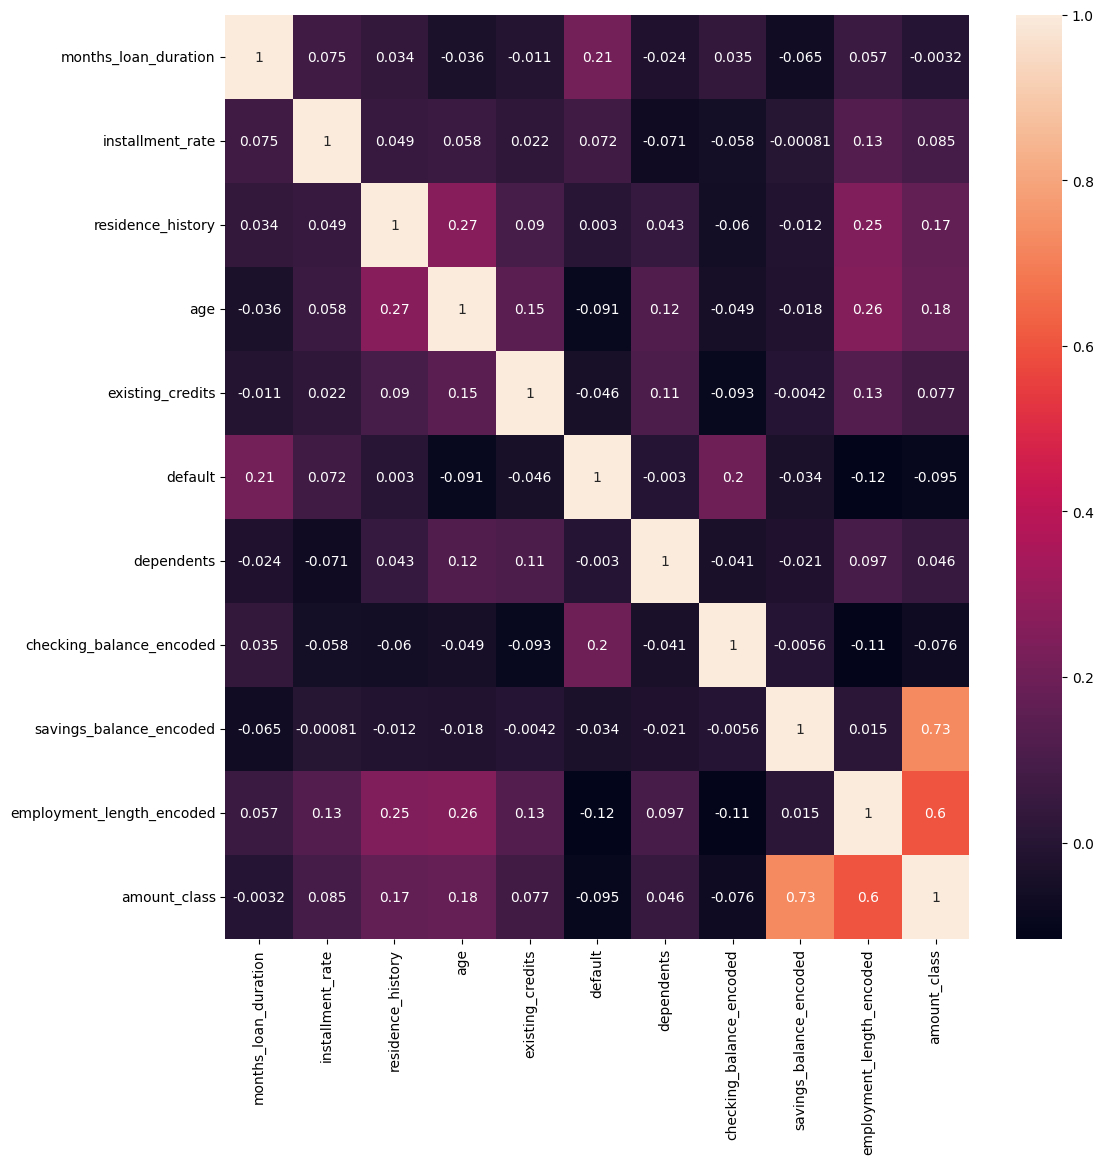

In [35]:
# matrice de corrélation NOUVELLE AVEC DE MEILLEUR DONNEE
plt.figure(figsize=(12,12))
sns.heatmap(data.select_dtypes(include=['number']).corr(),annot=True)

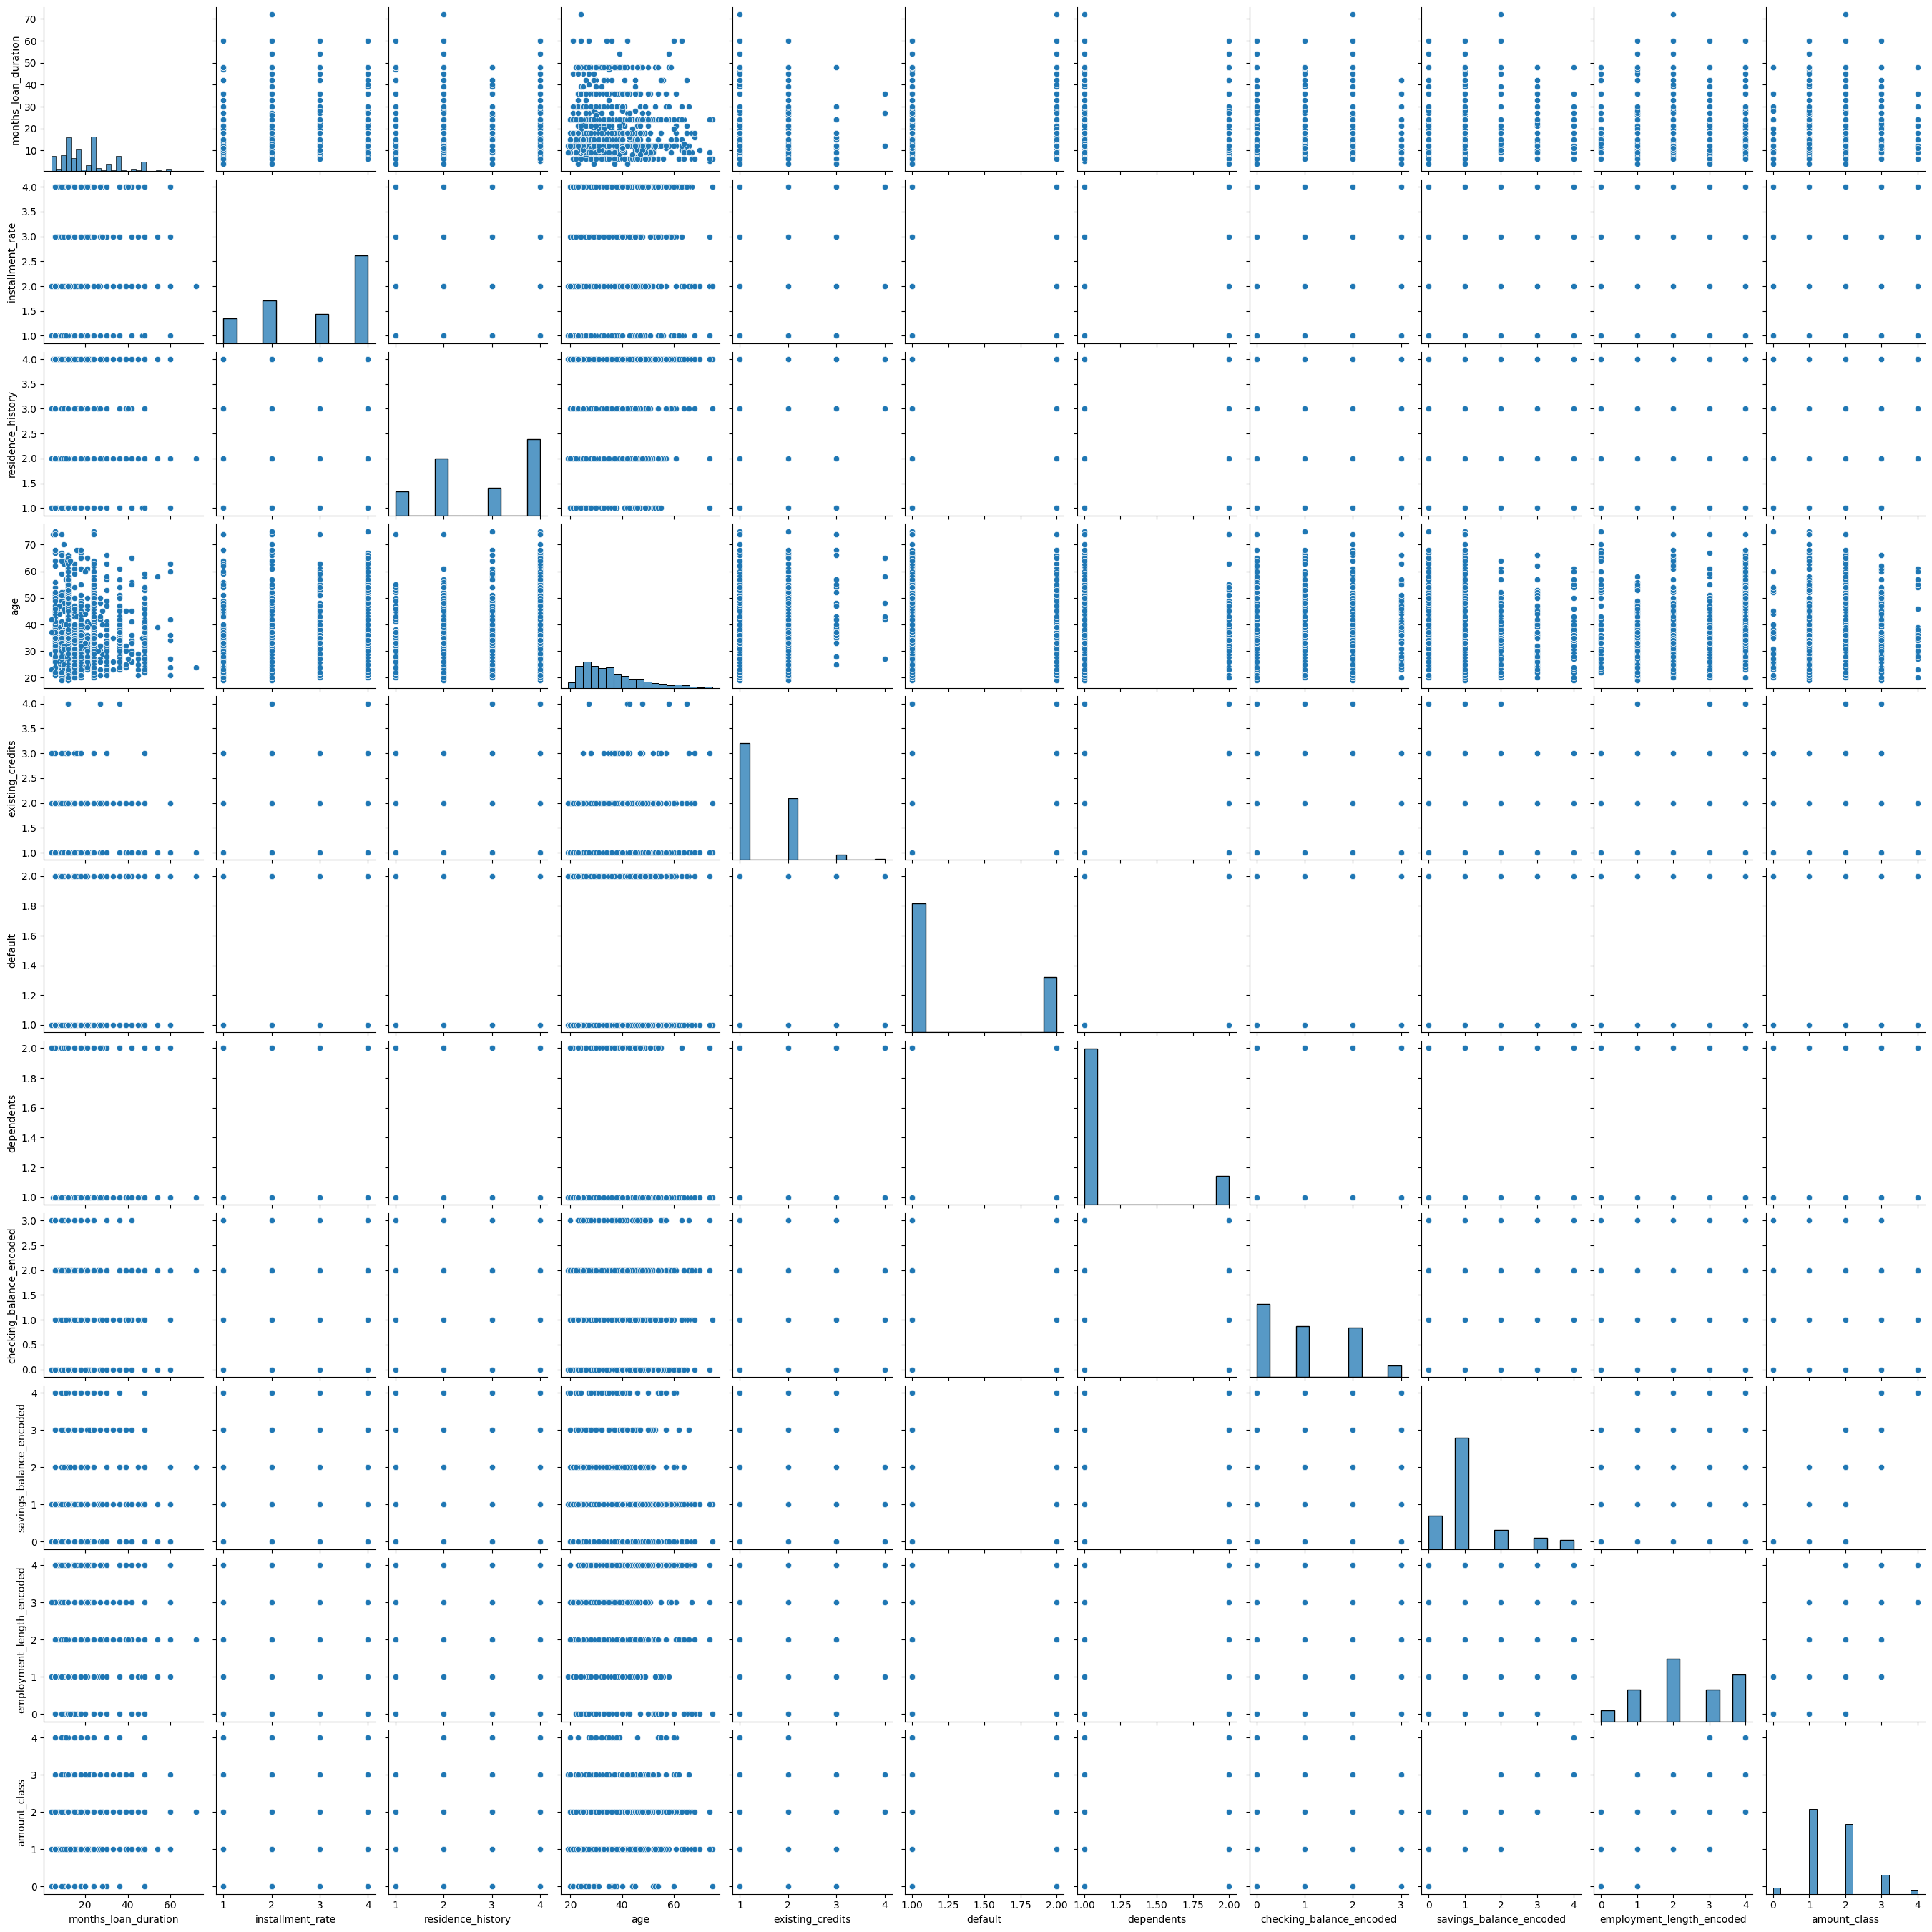

In [36]:
# Visualisation des données avec un pairplot
sns.pairplot(data.select_dtypes(include=['number']))

<Axes: xlabel='savings_balance_encoded', ylabel='amount_class'>

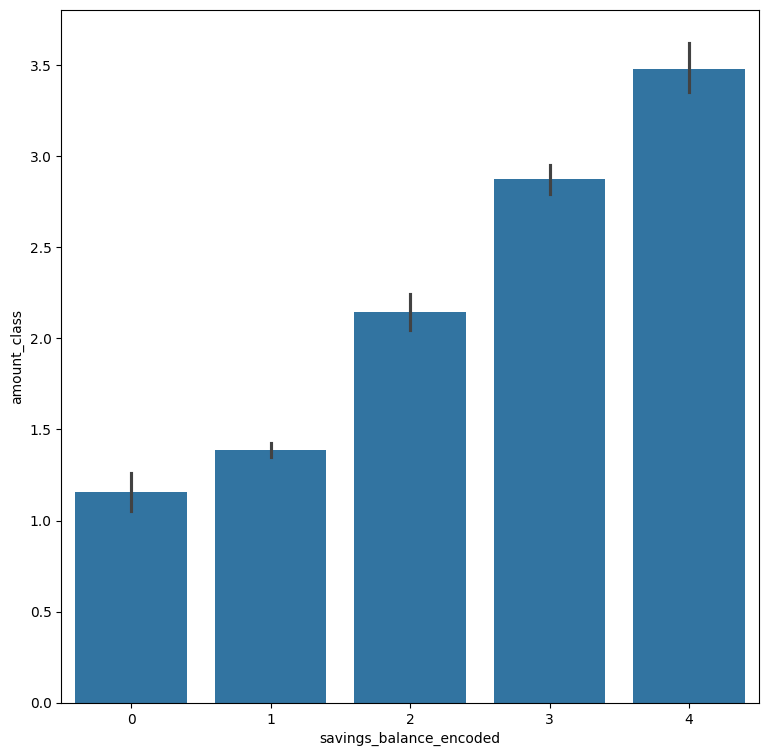

In [38]:
#FAIRE UN BOXPLOT SUR LES CLASSES_AMOUNT ET LES SAVINGS_ACCOUNT
plt.figure(figsize=(9,9))
sns.barplot(x='savings_balance_encoded',y='amount_class',data=data)

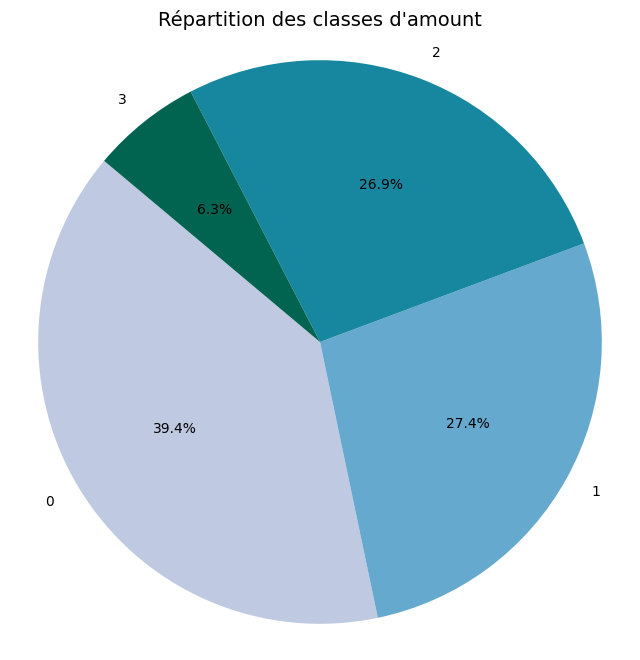

In [39]:
import matplotlib.cm as cm

# Compter les occurrences par classe
amount_counts = data['checking_balance_encoded'].value_counts()

# Générer un dégradé de turquoise (utilise la colormap 'PuBuGn' ou 'Blues' comme base turquoise)
colors = cm.PuBuGn(np.linspace(0.3, 0.9, len(amount_counts)))  # De plus clair à plus foncé

# Créer le diagramme circulaire avec dégradé
plt.figure(figsize=(8, 8))
plt.pie(
    amount_counts,
    labels=amount_counts.index,
    autopct='%1.1f%%',
    startangle=140,
    colors=colors
)
plt.title("Répartition des classes d'amount", fontsize=14)
plt.axis('equal')  # Pour garder le cercle parfait
plt.show()

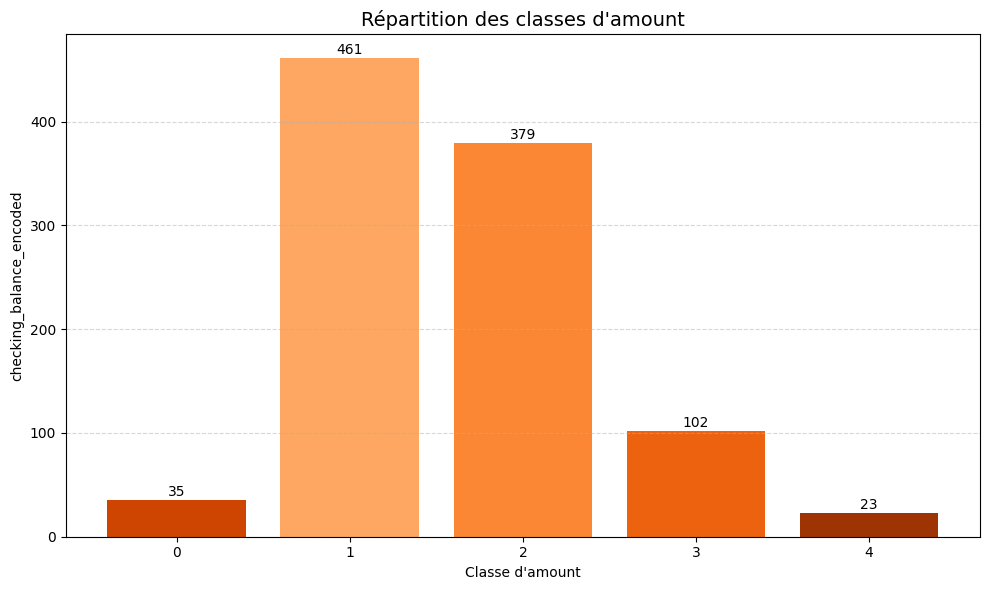

In [40]:
import matplotlib.cm as cm

# Compter les occurrences de amount_class
savings_counts = data['amount_class'].value_counts()

# Générer un dégradé orange (colormap Oranges)
colors = cm.Oranges(np.linspace(0.4, 0.9, len(savings_counts)))

# Créer le graphique
plt.figure(figsize=(10, 6))
bars = plt.bar(savings_counts.index, savings_counts.values, color=colors)

# Ajouter les valeurs au-dessus des barres
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, yval + 1, int(yval), ha='center', va='bottom')

plt.title("Répartition des classes d'amount", fontsize=14)
plt.xlabel("Classe d'amount")
plt.ylabel("checking_balance_encoded")
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

C:\Users\JOHANN\AppData\Local\Temp\ipykernel_15800\1277449683.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


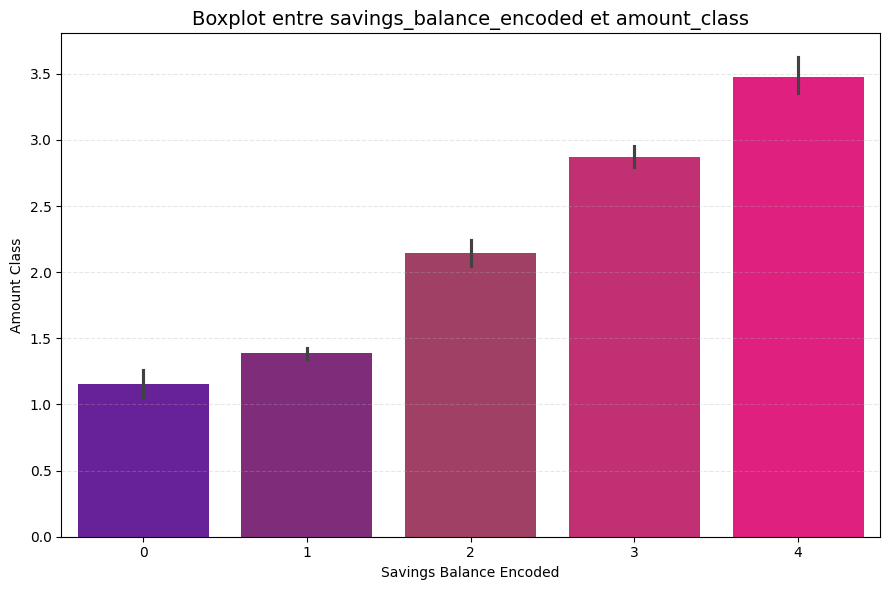

In [42]:
# Créer une palette de dégradé violet -> rouge
from matplotlib.colors import LinearSegmentedColormap

# Dégradé de violet à rouge
colors = ['#6a0dad', '#b03060', '#ff007f']  # violet, rose foncé, rouge framboise
custom_cmap = LinearSegmentedColormap.from_list("violet_red", colors)

# Générer la palette pour chaque barre
num_categories = data['savings_balance_encoded'].nunique()
palette = [custom_cmap(i / (num_categories - 1)) for i in range(num_categories)]

# Tracer le barplot
plt.figure(figsize=(9, 6))
sns.barplot(
    x='savings_balance_encoded',
    y='amount_class',
    data=data,
    palette=palette
)

plt.title("Boxplot entre savings_balance_encoded et amount_class", fontsize=14)
plt.xlabel("Savings Balance Encoded")
plt.ylabel("Amount Class")
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()


In [43]:
#Faire une matrice de correlation avec des colonnes jugé importante. En voulant faire une matrice generale les données etait illisibles
df =data[['checking_balance_encoded','savings_balance_encoded','employment_length_encoded']]

In [44]:
#Afficher le jeu de données
df.head()

,checking_balance_encoded,savings_balance_encoded,employment_length_encoded
0,1,0,4
1,2,1,2
2,0,1,3
3,1,1,3
4,1,1,2


<Axes: >

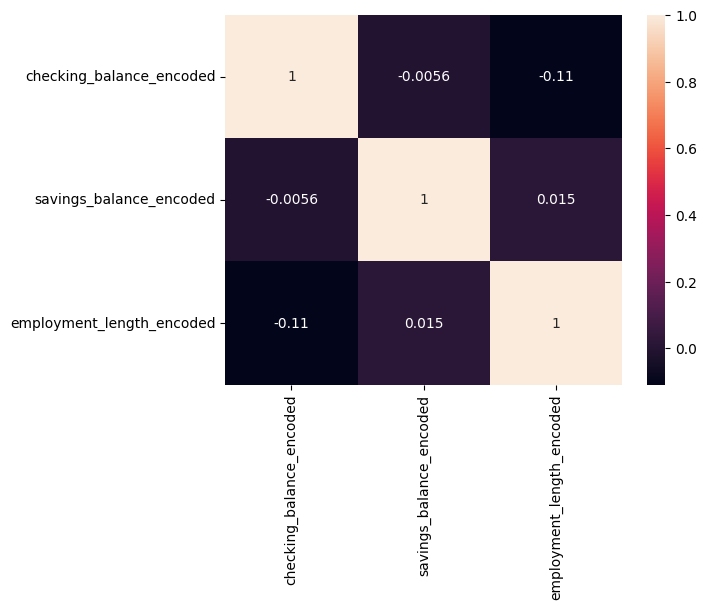

In [45]:
#Faire une matrice de correlation avec des colonnes jugé importante. En voulant faire une matrice generale les données etait illisibles
sns.heatmap(df.corr(),annot=True)

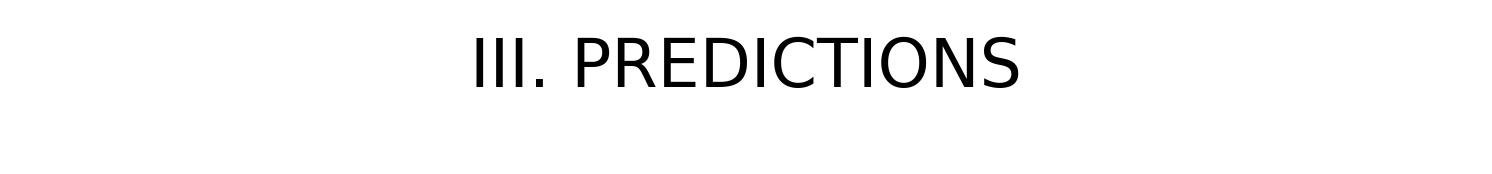

In [46]:
#CE CODE ME SERVIRA A AFFICHER LES GRANDS TITRE
commentaire = "III. PREDICTIONS"
plt.figure(figsize=(19,2))
plt.text(0.5, 0.5, commentaire, fontsize=48, ha="center")
plt.axis("off")
plt.show()

In [48]:
# Sélection des colonnes numériques
numerical_cols = [
    'months_loan_duration', 'installment_rate', 'residence_history',
    'age', 'existing_credits', 'default', 'dependents',
    'checking_balance_encoded', 'savings_balance_encoded', 'employment_length_encoded'
]



# X et y
X = data[numerical_cols]
y = data['amount_class']


In [49]:
#J'importe les bibliothèque pour la prediction et l'enregistrement des modeles
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import joblib

In [50]:
#80% pour l'entrainement et 20% pour le test
x_train,x_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=0)

In [51]:
# je normalise mes données
scaler=StandardScaler()
x_train=scaler.fit_transform(x_train)
x_test=scaler.transform(x_test)
x_train

array([[ 1.26614168,  0.90367954,  0.12845118, ...,  1.04221659,
         0.82183781,  1.31728192],
       [ 0.27024163,  0.90367954, -1.70656566, ..., -0.00392302,
        -0.20225915, -1.17599616],
       [ 3.25794179,  0.90367954, -0.78905724, ...,  1.04221659,
         0.82183781, -1.17599616],
       ...,
       [-0.97463344, -1.79723067,  1.0459596 , ..., -1.05006264,
        -1.2263561 ,  1.31728192],
       [-0.2277084 , -0.89692727, -0.78905724, ...,  1.04221659,
        -0.20225915, -1.17599616],
       [ 1.26614168, -1.79723067,  0.12845118, ...,  1.04221659,
         0.82183781,  0.48618922]], shape=(800, 10))

In [52]:
# Entraînement XGBoost
from xgboost import XGBClassifier
model = XGBClassifier(
    n_estimators=100,
    max_depth=4,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    use_label_encoder=False,
    eval_metric='mlogloss'
)

model.fit(x_train, y_train)

c:\Users\JOHANN\Documents\environement python\IABD\IABDJOHANN\lib\site-packages\xgboost\training.py:183: UserWarning: [19:46:49] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='mlogloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=4, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=100, n_jobs=None,
              num_parallel_tree=None, ...)

<Axes: >

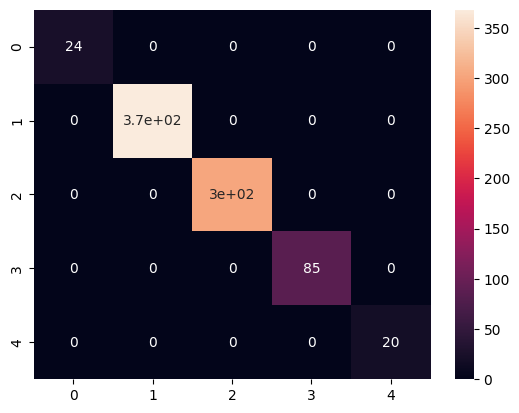

In [53]:
#Je crée une matrice de confusion pour ce modele
y_predict_train=model.predict(x_train) # type: ignore
from sklearn.metrics import confusion_matrix
cm=confusion_matrix(y_train,y_predict_train)
sns.heatmap(cm,annot=True)

In [54]:
#j'affiche toutes les metriques
from sklearn.metrics import classification_report
print(classification_report(y_train,y_predict_train))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        24
           1       1.00      1.00      1.00       368
           2       1.00      1.00      1.00       303
           3       1.00      1.00      1.00        85
           4       1.00      1.00      1.00        20

    accuracy                           1.00       800
   macro avg       1.00      1.00      1.00       800
weighted avg       1.00      1.00      1.00       800



In [55]:
#CROSS VALIDATION POUR MON MODELE
from sklearn.model_selection import cross_val_score
scores= cross_val_score(model,x_train,y_train,cv=6)

c:\Users\JOHANN\Documents\environement python\IABD\IABDJOHANN\lib\site-packages\xgboost\training.py:183: UserWarning: [19:46:50] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\JOHANN\Documents\environement python\IABD\IABDJOHANN\lib\site-packages\xgboost\training.py:183: UserWarning: [19:46:50] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\JOHANN\Documents\environement python\IABD\IABDJOHANN\lib\site-packages\xgboost\training.py:183: UserWarning: [19:46:50] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\JOHANN\Documents\environement python\IABD\IABDJOHANN\lib\site-packages\xgboost\training.py:183: UserWarning: 

In [56]:
#AFFICHER LES SCORE DE VALIDATION CROISEE
print("Scores de validation croisée:",scores)
print("Moyenne de validation croisée:",scores.mean())

Scores de validation croisée: [1.         1.         0.98496241 1.         0.98496241 0.97744361]
Moyenne de validation croisée: 0.9912280701754385


In [57]:
# Enregistrer le modèle
joblib.dump(model, 'JOHN_XGBOOST.pkl')
print("Modèle enregistré sous 'JOHN_XGBOOST.pkl'")

Modèle enregistré sous 'JOHN_XGBOOST.pkl'
